In [12]:
from get_noise_sigma import load_dataset

dataset_name = ['TIMIT-sentence_type-16k', 'TIMIT-gender-16k', 'TIMIT-dialect-16k']
for dataset in dataset_name:
    data = load_dataset(dataset)

    import numpy as np 
    key1 = 'TRAIN'
    audio = {key1: {}}
    for key2 in data[key1].keys():
        audio[key1][key2] = {}
        for key3 in data[key1][key2].keys():
            l = [(10 ** (i / 10)).sum(axis=-1).mean() for i in data[key1][key2][key3]]
            # print(l, np.mean(l), np.std(l))
            audio[key1][key2][key3] = l
    # audio

    key1 = 'TRAIN'
    s = []
    for key2 in audio[key1].keys():
        for key3 in audio[key1][key2].keys():
            s.append(np.mean(audio[key1][key2][key3]))
    np.mean(s)

    from get_noise_sigma import get_gaussian_sigma
    print(f'=========={dataset}==========')
    print("H, -15dB:", get_gaussian_sigma(np.mean(s), -15))
    print("H, 0dB:", get_gaussian_sigma(np.mean(s), 0))
    print("M, 15dB:", get_gaussian_sigma(np.mean(s), 15)) 
    print("L, 25dB:", get_gaussian_sigma(np.mean(s), 25))

==========TIMIT-sentence_type-16k==========
H, -15dB: 2.9378581810607165
H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162
==========TIMIT-gender-16k==========
H, -15dB: 2.9378581810607165
H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162
==========TIMIT-dialect-16k==========
H, -15dB: 2.923286941982042
H, 0dB: 0.5198420978562313
M, 15dB: 0.09244244990891749
L, 25dB: 0.02923286941982042


[0.089629374, 0.041464183, 0.11858334, 0.16153274, 0.050829858, 0.060000926, 0.13232893, 0.06755879, 0.05270852, 0.07225126] 0.08468879 0.038003914
[0.062520005, 0.06632189, 0.094079874, 0.031372614, 0.11210103, 0.048817053, 0.101130076, 0.022933563, 0.04744995, 0.05331992] 0.0640046 0.028238663
[1.0367779, 0.686923, 0.33161125, 0.63832223, 0.39068174, 0.6868043, 0.52359587, 0.37247285, 0.8184773, 1.100141] 0.6585807 0.25383916
[0.14132035, 0.02731764, 0.02576074, 0.029238641, 0.11230475, 0.77074605, 0.14663908, 0.073515184, 0.239747, 0.16834569] 0.17349352 0.20991056
[0.3265791, 0.41441846, 0.34657043, 0.49873298, 0.64668745, 0.5537158, 0.52055687, 0.27899647, 0.55449945, 0.38237306] 0.452313 0.11343491
[0.43603998, 0.7577529, 1.0446594, 0.5803714, 3.7371156, 1.1710082, 1.9696954, 1.0841106, 0.6423727, 1.2967948] 1.2719922 0.9219237
[0.12096071, 0.08852404, 0.13972211, 0.042059932, 0.07482224, 0.068001404, 0.06315132, 0.034956384, 0.073105015, 0.09316684] 0.079847 0.03075853
[0.775334

0.27293652

H, 0dB: 0.5224332712994674
M, 15dB: 0.09290323294711213
L, 25dB: 0.029378581810607162


In [7]:
np.mean(s)

0.27293652

In [6]:
snr_db = 0
(10 ** (snr_db/10))

1.0

In [33]:
key1 = 'TRAIN'
db = []
for key2 in audio[key1].keys():
    for key3 in audio[key1][key2].keys():
        db.append(10 * np.log10(np.array(audio[key1][key2][key3]) / 0.2729))
np.concatenate(db).mean()

-1.9086657

In [2]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(H)', "GaussianNoise(M)", "GaussianNoise(L)"]
for train_post in post:
    for test_post in post:
        path = f'./noise/training/TIMIT-dialect-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_{train_post}_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(train_post, test_post, data)

GaussianNoise(H) GaussianNoise(H) {'accuracy': {'all': 0.13421052631578947}, 'uar': {'all': 0.11535599816849816}, 'f1': {'all': 0.08501588265632841}, 'loss': {'all': 1.9917313555876415}}
GaussianNoise(H) GaussianNoise(M) {'accuracy': {'all': 0.1355263157894737}, 'uar': {'all': 0.11655792124542125}, 'f1': {'all': 0.08691998329264414}, 'loss': {'all': 1.9922959208488464}}
GaussianNoise(H) GaussianNoise(L) {'accuracy': {'all': 0.1355263157894737}, 'uar': {'all': 0.11680593711843712}, 'f1': {'all': 0.08710870321053785}, 'loss': {'all': 1.9925224383672078}}
GaussianNoise(M) GaussianNoise(H) {'accuracy': {'all': 0.15526315789473685}, 'uar': {'all': 0.14753042096792096}, 'f1': {'all': 0.13124778103073814}, 'loss': {'all': 1.9216794669628143}}
GaussianNoise(M) GaussianNoise(M) {'accuracy': {'all': 0.14605263157894738}, 'uar': {'all': 0.14244436119436119}, 'f1': {'all': 0.1195598804475277}, 'loss': {'all': 1.913279265165329}}
GaussianNoise(M) GaussianNoise(L) {'accuracy': {'all': 0.146052631578

In [19]:
import pandas as pd 
import yaml 
post = ['GaussianNoise(HH)', 'GaussianNoise(H)', "GaussianNoise(M)", "GaussianNoise(L)"]
datasets = ['TIMIT-sentencetype-16k', 'TIMIT-dialect-16k', "TIMIT-gender-16k"]
for dataset in datasets:
    for test_post in post:
        # path = f'./noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_10_None_None_{test_post}_0/_test/test_holistic.yaml'
        path = f'./results/noise/training/{dataset}_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_{test_post}_0/_test/test_holistic.yaml'
        # res = pd.read_csv(path)
        # print(f"{train_post}+{test_post}: \t{res['accuracy'].max()}\t{res['uar'].max()}\t{res['f1'].max()}")
        with open(path) as f:
            data = yaml.load(f, Loader=yaml.FullLoader)
        print(f"====={dataset}=====")
        print(test_post, data)  

=====TIMIT-sentencetype-16k=====
GaussianNoise(HH) {'accuracy': {'all': 0.6529761904761905}, 'uar': {'all': 0.671957671957672}, 'f1': {'all': 0.6713679473573726}, 'loss': {'all': 0.5255221558941735}}


FileNotFoundError: [Errno 2] No such file or directory: './results/noise/training/TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_5_None_None_GaussianNoise(H)_0/_test/test_holistic.yaml'

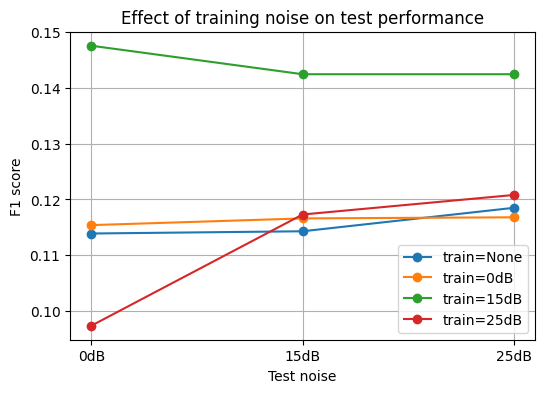

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ("None", "0dB", 0.1139),
    ("None", "15dB", 0.1143),
    ("None", "25dB", 0.1185),
    ("0dB", "0dB", 0.1154),
    ("0dB", "15dB", 0.1166),
    ("0dB", "25dB", 0.1168),
    ("15dB", "0dB", 0.1475),
    ("15dB", "15dB", 0.1424),
    ("15dB", "25dB", 0.1424),
    ("25dB", "0dB", 0.0974),
    ("25dB", "15dB", 0.1173),
    ("25dB", "25dB", 0.1208),
]
df = pd.DataFrame(data, columns=["train", "test", "F1"])

plt.figure(figsize=(6,4))
for train in df["train"].unique():
    subset = df[df["train"] == train]
    plt.plot(subset["test"], subset["F1"], marker="o", label=f"train={train}")
plt.xlabel("Test noise")
plt.ylabel("F1 score")
plt.title("Effect of training noise on test performance")
plt.legend()
plt.grid(True)
plt.show()


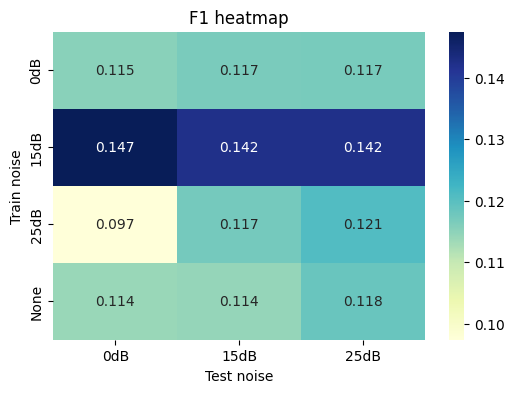

In [11]:
import seaborn as sns
pivot = df.pivot(index="train", columns="test", values="F1")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("F1 heatmap")
plt.ylabel("Train noise")
plt.xlabel("Test noise")
plt.show()
